# 1. Импортируем основные рабочие библиотеки
---

In [1]:
import pandas as pd
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np
from scipy import stats
import pingouin as pg
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')

# 2. Импортируем данные
---

In [2]:
#Группа Control1
c1_users, c1_transactions = (
    pd.read_csv('Проект_3_users_control_1.csv', sep=';'),
    pd.read_csv('Проект_3_transactions_control_1.csv', sep=';')
)
#Группа Control2
c2_users, c2_transactions = (
    pd.read_csv('Проект_3_users_control_2.csv', sep=';'),
    pd.read_csv('Проект_3_transactions_control_2.csv', sep=';')
)
#Группа test
t_users, t_transactions = (
    pd.read_csv('Проект_3_users_test.csv', sep = ';'),
    pd.read_csv('Проект_3_transactions_test.csv', sep = ';'),
)

# 3. Первичная проверка и обработка
---

In [3]:
# функция для общего первичного изучения и проверки
def insp_df(df):
    print("▶️ Общая информация:")
    print(df.info())
    
    print("\n▶️ Первые строки:")
    print(df.head())

    print("\n▶️ Типы данных:")
    print(df.dtypes)

    print(f"\n▶️ Размерность: {df.shape[0]} строк, {df.shape[1]} столбцов")

    print("\n▶️ Кол-во дубликатов строк:", df.duplicated().sum())
    # Для удаления:
    # df.drop_duplicates(inplace=True)

    print("\n▶️ NaN значения по столбцам:")
    print(df.isna().sum())

    print("\n▶️ Процент пропущенных значений:")
    print((df.isna().mean() * 100).round(2).sort_values(ascending=False))

    print("\n▶️ Описательная статистика по числовым колонкам:")
    print(df.describe())

    print("\n▶️ Уникальные значения в строковых/категориальных колонках:")
    for col in df.select_dtypes(include=['object', 'category']).columns:
        print(f"• {col}: {df[col].nunique()} уникальных -> {df[col].unique()[:5]}...")

    df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)

    print("\n✅ Проверка завершена.")
    return df  #Обработанный

# Сделаем также ф-цию для преобразования нужных колонок в DateTime
def to_date(lst):
    for df, columns in lst:
        for col in columns:
            df[col] = pd.to_datetime((df[col]), errors = 'coerce')

In [4]:
#Первая контрольная
insp_df(c1_users)
insp_df(c1_transactions)
c1_transactions = c1_transactions.dropna()
#Вторая контрольная
insp_df(c2_users)
insp_df(c2_transactions)
#Тестовая
insp_df(t_users)
insp_df(t_transactions)
#А теперь преобразуем даты
to_date([
    (c1_transactions, ['joined_at','paid_at']),
    (c2_transactions, ['joined_at','paid_at']),
    (t_transactions, ['joined_at','paid_at']),
])
#A теперь удалим дубликаты
c1_transactions.drop_duplicates(inplace=True)
c2_transactions.drop_duplicates(inplace=True)
t_transactions.drop_duplicates(inplace=True)
for df in [c1_users, c2_users, t_users]:
    df.fillna(0,inplace = True)

▶️ Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4340 non-null   int64  
 1   age               4340 non-null   int64  
 2   attraction_coeff  4340 non-null   int64  
 3   coins             60 non-null     float64
 4   country           4340 non-null   object 
 5   visit_days        3016 non-null   object 
 6   gender            4340 non-null   int64  
 7   age_filter_start  4340 non-null   int64  
 8   age_filter_end    4340 non-null   int64  
 9   views_count       4340 non-null   int64  
 10  was_premium       436 non-null    float64
 11  is_premium        192 non-null    float64
 12  total_revenue     4340 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 440.9+ KB
None

▶️ Первые строки:
         uid  age  attraction_coeff  coins                   country  \
0  8923

##  Базовые сведения о группах

---

### 🔹 Control_1

####  C1_Users
- Типы данных — без дат.  
- 4340 строк (пользователей).  
- Дубликатов **нет**. Пропущенные значения можно заменить на нули — это соответствует смыслу.  
- Возраст:
  - Средний: 32  
  - Медиана: 30  
  - Разброс: от 16 до 99  
  - Межквартильный интервал: 24–38  
- Revenue:
  - Среднее: 595  
  - 40 стран  
- ⚠️ Подозрительный выброс по `revenue`, из-за которого отличается от второй контрольной.

####  C1_Transactions
- Типы данных — без дат (а они **есть**).  
- 1007 строк, 8 столбцов  
- 650 дубликатов (??), 630 пропущенных значений (включая `uid`) → это "хвост".  
- Страны: 18 (на самом деле 17 + `NaN`)  
- 24 уникальных страницы перехода  
- Средняя выручка: 6929  
- Реальных строк около **377**  
- ➤ Можно смело удалять `NaN`

---

### 🔹 Control_2

####  C2_Users
- 4264 уникальных пользователей  
- Дубликатов нет, `NaN` нет  
- Возраст и привлекательность — **аналогичны** первой группе  
- `coins` — **существенные отличия**  
- Пол, возрастные предпочтения — сопоставимы  
- Кол-во `premium` пользователей аналогично, `was_premium` на **5% ниже**  
- Средний `revenue` — **меньше**, чем в первой  
- По странам аналогично — 40

####  C2_Transactions
- Чистый DataFrame, **без хвоста**  
- Медиана `revenue` существенно ниже (4700 против 6250)  
- Страны: на 1 больше  
- Источников перехода: 18 против 25  
- Транзакций: 328 против 377  
- ➤ В целом, у второй контрольной **все показатели ниже**

---

### 🔹 Test

####  T_Users
- 4308 пользователей (всего на ~0.7% меньше)  
- `NaN` аномалий нет  
- `premium`: 157 (меньше, чем в control_1: 192, и control_2: 191)  
- `was_premium`: 408 против 436 и 450  
- Возраст, пол, предпочтения — **почти идентичны**  
- ⚠️ **Сильно больше стран** — 51 против 40  
  - Проверить распределение и выбросы по странам  
  - Потенциально некорректное сплитование  
- ⚠️ Меньше премиум-пользователей на ~18%

####  T_Transactions
- Чистый df  
- Транзакций меньше: 273 (vs 323 и 377)  
- Стран: 17  
  - Проверить — возможно, это ключевая причина различий  
- Средняя выручка: 8589  
- Медиана `revenue`: 6300 — сопоставима с первой контрольной  
- ⚠️ Очень высокая разница в 75% перцентиле — **в 2 раза выше**, чем у других  
  - Меньше транзакций, но они крупнее → смещение в выручке

---

##  Общие баги

- Дубликаты в каждом `transactions`-df  
- Не может быть полных дубликатов в платежах: они детализированы до `payment_id` и минуты  
- ➤ **Удаляем дубликаты**

---

##  После удаления дубликатов

| Группа   | Транзакции | Страны | Источники | Медиана | 75% | Среднее | Max |
|----------|------------|--------|-----------|---------|-----|----------|------|
| Control 1 | 356        | 18     | 25        | 6292    | 7312 | 7007     | —    |
| Control 2 | 323        | 19     | 18        | 4700    | 6350 | 5900     | —    |
| Test      | 266        | 17     | 22        | 6363    | 12597 | 8767   | 113477 |

---

###  Предобработка завершена


In [5]:
#попробуем посмотреть, сколько месяцев наблюдения у нас имеется
t_transactions['trans_month'] = t_transactions.paid_at.dt.to_period('M') #месяц транзакции
c1_transactions['trans_month'] = c1_transactions.paid_at.dt.to_period('M') #месяц транзакции
c2_transactions['trans_month'] = c2_transactions.paid_at.dt.to_period('M') #месяц транзакции
t_transactions.groupby('trans_month').size() #абсолютное большинство в окт 17. Вероятно, это и есть месяц теста. Диапазон - 17 год
c1_transactions.groupby('trans_month').size() #Есть лишний декабрь 16. Стоит убрать его. Также 17 год, основное - октябрь
c2_transactions.groupby('trans_month').size() #Также 17 год, без аномалий.
c1_transactions[c1_transactions['uid'].isin(c1_transactions.loc[c1_transactions['trans_month'] == '2016-12', 'uid'])] # у аномальных пользователей за 16 год и правда платежи только в 16. Это облегчает задачу - просто удаляем.
#почистим c1_transactions
c1_transactions = c1_transactions[~c1_transactions['uid'].isin(c1_transactions.loc[c1_transactions['trans_month'] == '2016-12', 'uid'])]
c1_transactions.shape # Успех

(353, 9)

In [8]:
#Посмотрим на предмет возможных аномалий в датах, времени тразнакций
c1_transactions['period_join_paid'] = c1_transactions.paid_at - c1_transactions.joined_at
c1_transactions[['uid','joined_at', 'paid_at',  'period_join_paid']].sort_values(by='period_join_paid') #Подозрительные аномалии есть, посмотрим количество
c1_transactions[c1_transactions['period_join_paid'] < pd.Timedelta(0)] #55 Значений. Если искать по id - то есть и те, которые с нормальными транзакциями
# Все происходят в 11 число!!
c2_transactions['period_join_paid'] = c2_transactions.paid_at - c2_transactions.joined_at
c2_transactions[['uid','joined_at', 'paid_at',  'period_join_paid']].sort_values(by='period_join_paid')
c2_transactions[c2_transactions['period_join_paid'] < pd.Timedelta(0)]#60 значений. Тоже транзакции 11 числа

t_transactions['period_join_paid'] = t_transactions.paid_at - t_transactions.joined_at
t_transactions[['uid','joined_at', 'paid_at',  'period_join_paid']].sort_values(by='period_join_paid')
t_transactions[t_transactions['period_join_paid'] < pd.Timedelta(0)]#47 значений. Тоже транзакции 11 числа.


# Отбросим аномальные значения, т.к. их происхождение неясно, могут негативно повлиять на тест.

c1_transactions = c1_transactions[c1_transactions['period_join_paid'] >= pd.Timedelta(0)]
c2_transactions = c2_transactions[c2_transactions['period_join_paid'] >= pd.Timedelta(0)]
t_transactions = t_transactions[t_transactions['period_join_paid'] >= pd.Timedelta(0)]
c2_transactions.shape

(263, 10)

# 3. EDA – Исследовательский анализ данных

### 3.1. Распределения по демографии и фильтрам

- Изучим распределения по:
  - **странам**
  - **полу**
  - **возрасту**
  - **фильтрам**
  - **монетам**

- **Проверим корректность сплитования по группам**:
  - Используем ANOVA для числовых признаков
    - Если ANOVA показала статистическую значимость → применим **Tukey HSD**
  - Проверим равенство дисперсий с помощью **теста Левена**

---

### 3.2. Поведенческие метрики

- Проанализируем поведение пользователей:
  - **visit_days**
  - **was_premium**
  - **is_premium**

⚠️ Обратить особое внимание на метрику **is_premium**, так как изменение стоимости подписки в тестовой группе **могло повлиять** на поведение.

---

### 3.3. Сравнение метрик и дисперсий по группам

- Средние и дисперсии:
  - **Возраст**: среднее и дисперсия
  - **Пол**: доля женщин / мужчин
  - **Доля платящих пользователей**
  - **attraction_coeff** и **views_count**

- Методы сравнения:
  - **Boxplot**, **Histogram**, **Bar chart** для визуального анализа
  - Для категориальных признаков применяем **χ²-тест (хи-квадрат)**

---


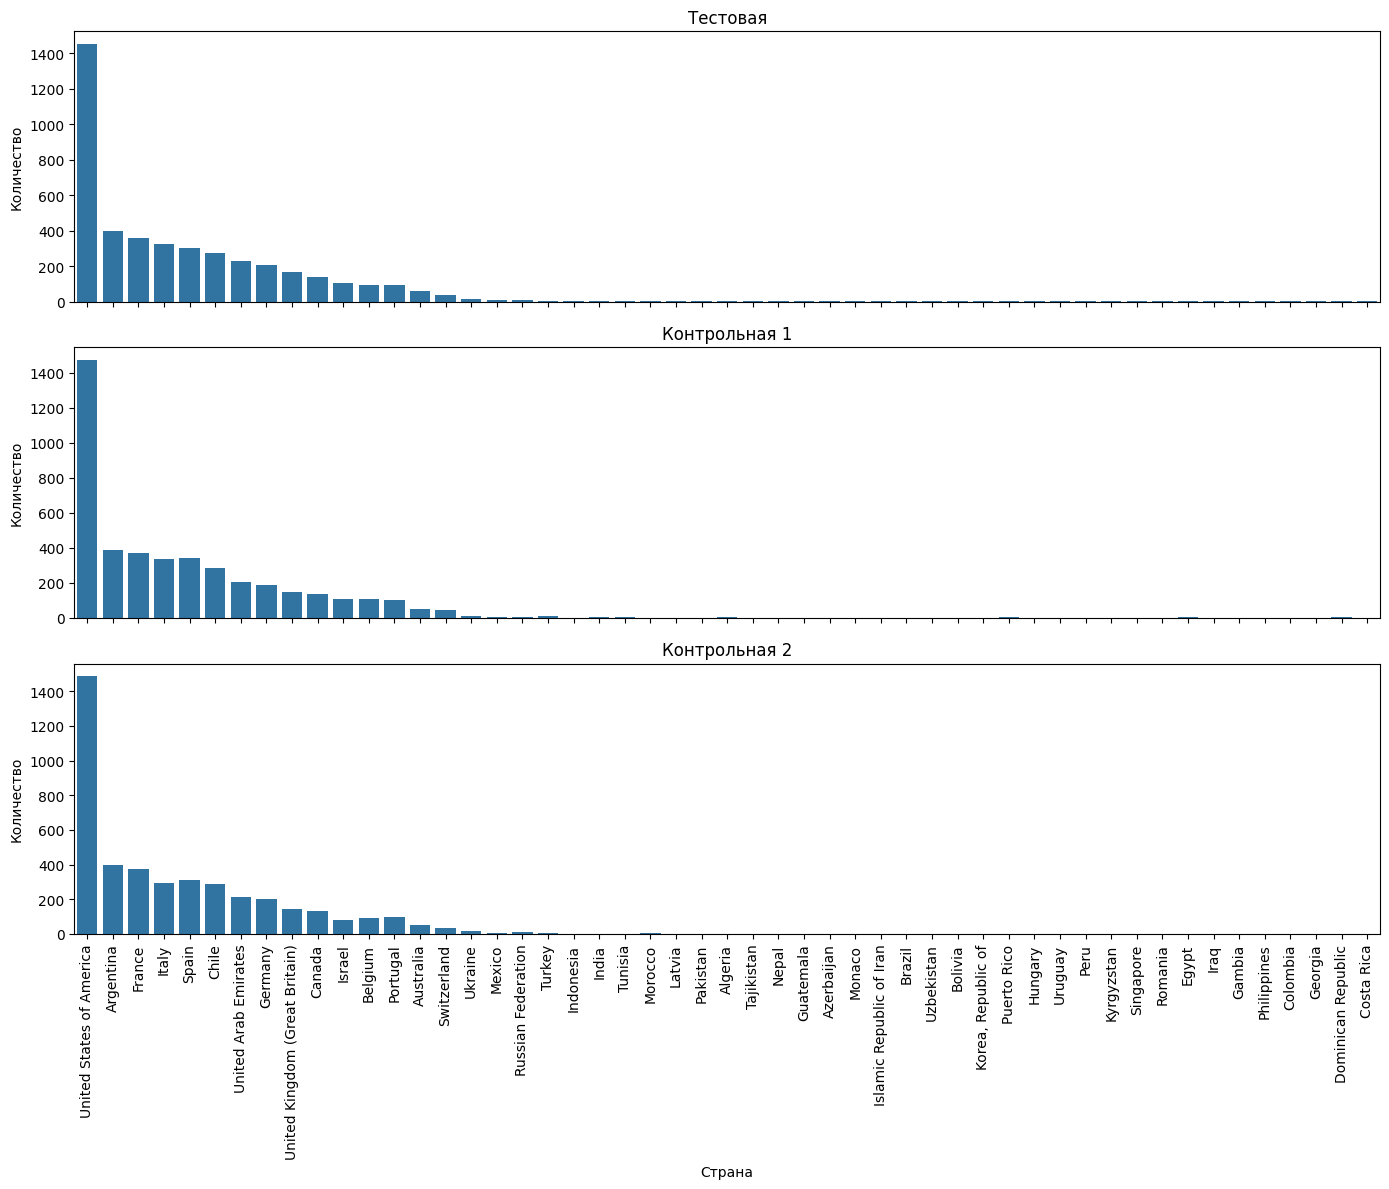

(country    Argentina  Australia   Belgium    Canada     Chile  Czech Republic  \
 group                                                                           
 control_1   1.571675   1.886010  0.314335  4.086356  1.257340        0.314335   
 control_2   1.683938   2.020725  0.336788  4.378238  1.347150        0.336788   
 test        1.744387   2.093264  0.348877  4.535406  1.395509        0.348877   
 
 country      France    Gambia   Germany     Israel  ...    Latvia  Portugal  \
 group                                               ...                       
 control_1  5.343696  0.314335  3.457686   9.115717  ...  0.314335  0.314335   
 control_2  5.725389  0.336788  3.704663   9.766839  ...  0.336788  0.336788   
 test       5.930915  0.348877  3.837651  10.117444  ...  0.348877  0.348877   
 
 country    Russian Federation     Spain  Switzerland    Turkey   Ukraine  \
 group                                                                      
 control_1            2.514680  

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# t_users
sns.countplot(ax=axes[0], data=t_users, x='country', order=t_users['country'].value_counts().index)
axes[0].set_title('Тестовая')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=90)

# c1_users)
sns.countplot(ax=axes[1], data=c1_users, x='country', order=t_users['country'].value_counts().index)
axes[1].set_title('Контрольная 1')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=90)

# График для второй группы (например, c2_users)
sns.countplot(ax=axes[2], data=c2_users, x='country', order=t_users['country'].value_counts().index)
axes[2].set_title('Контрольная 2')
axes[2].set_ylabel('Количество')
axes[2].tick_params(axis='x', rotation=90)

plt.xlabel('Страна')
plt.tight_layout()
plt.show()

#Проверим сплитование по странам - распределение кат. переменных.
from scipy.stats import chi2_contingency
c1_users['group'] = 'control_1'
c2_users['group'] = 'control_2'
t_users['group'] = 'test'  
# Объединяем в один DataFrame
combined_users = pd.concat([c1_users, c2_users, t_users], ignore_index=True)
# Строим таблицу сопряженности: строки — группы, столбцы — страны
contingency = pd.crosstab(combined_users['group'], combined_users['country'])
chi2_contingency(contingency) #0.62 p-value - кат. распределение по странам сопоставимо, в этой части сплитование корректно

#Посмотрим еще на соотношение с фильтрацией по пользователям, бывшим платными (знаем, что в тестовой могут потенциально быть отклонения, обусловленные тестовыми изменениями)
# Фильтрация на бывших премиумов
combined_users[combined_users['was_premium'] == 1]

# Сырые данные — передаём сразу
pg.chi2_independence(data=combined_users[combined_users['was_premium'] == 1], x='group', y='country') #Удивительно, но все еще нет существенных различий P = 0.488411
pg.chi2_independence(data=combined_users[combined_users['is_premium'] == 1], x='group', y='country') # И опять нет различий 0.606704
pg.chi2_independence(data=combined_users[combined_users['coins'] != 0], x='group', y='country') # Тоже идентично 0.658155
pg.chi2_independence(data=combined_users[combined_users['gender'] != 1], x='group', y='country') # Тоже идентично 0.770440 

In [10]:
#Сравним на развернутой таблице, будет наглядней.
cntrs_pvt = pd.pivot_table(combined_users.groupby(['country', 'group'])['uid'].nunique().reset_index(), values='uid', index='group', columns='country')
cntrs_pvt.fillna(0, inplace = True)
# Получаем, как будто бы, бесполезных для теста пользователей в некоторых странах. Пожалуй, удалим их из всех датасетов.
small_cntrs = [x for x in cntrs_pvt.columns if (cntrs_pvt[x]==0).any()]
small_cntrs #внушительный список. попробуем удалить все транзакции и всех юзеров из этих стран.

combined_users = combined_users[~combined_users['country'].isin(small_cntrs)] # 12828

In [11]:
contingency = pd.crosstab(combined_users['group'], combined_users['country'])
chi2_contingency(contingency) 

Chi2ContingencyResult(statistic=np.float64(31.697954995678373), pvalue=np.float64(0.9664633964431885), dof=48, expected_freq=array([[3.97962114e+02, 5.48797162e+01, 9.76387590e+01, 1.36357577e+02,
        2.84499143e+02, 1.34674150e+00, 1.01005613e+00, 1.34674150e+00,
        3.72037340e+02, 2.01674540e+02, 4.04022451e+00, 9.86488151e+01,
        3.21197848e+02, 1.01005613e+00, 5.05028064e+00, 1.01005613e+00,
        9.79754443e+01, 7.07039289e+00, 3.20861163e+02, 3.77087621e+01,
        6.06033676e+00, 1.38041004e+01, 2.16825382e+02, 1.55211958e+02,
        1.48377245e+03],
       [3.90498597e+02, 5.38504833e+01, 9.58076084e+01, 1.33800281e+02,
        2.79163548e+02, 1.32148425e+00, 9.91113190e-01, 1.32148425e+00,
        3.65060025e+02, 1.97892267e+02, 3.96445276e+00, 9.67987215e+01,
        3.15173994e+02, 9.91113190e-01, 4.95556595e+00, 9.91113190e-01,
        9.61379794e+01, 6.93779233e+00, 3.14843623e+02, 3.70015591e+01,
        5.94667914e+00, 1.35452136e+01, 2.12758965e+02, 1.

##### 0.966 p-value После чистки Хи квадрат показал почти идентичное распределение между странами. Прекрасно

In [12]:
#Посмотрим-сравним число посещений
combined_users['days_total'] = combined_users['visit_days'].apply(lambda x: len(str(x).split(',')))
combined_users.groupby('group')['days_total'].sum() #Сопоставимо 20300-21472, тестовая посредине
pg.anova(data=combined_users, dv='days_total', between='group') #Не стат значимо, нулевая гипотеза (p 0,264); 0,26 после удаления несопоставимых стран

,Source,ddof1,ddof2,F,p-unc,np2
0,group,2,12825,1.329667,0.264602,0.000207


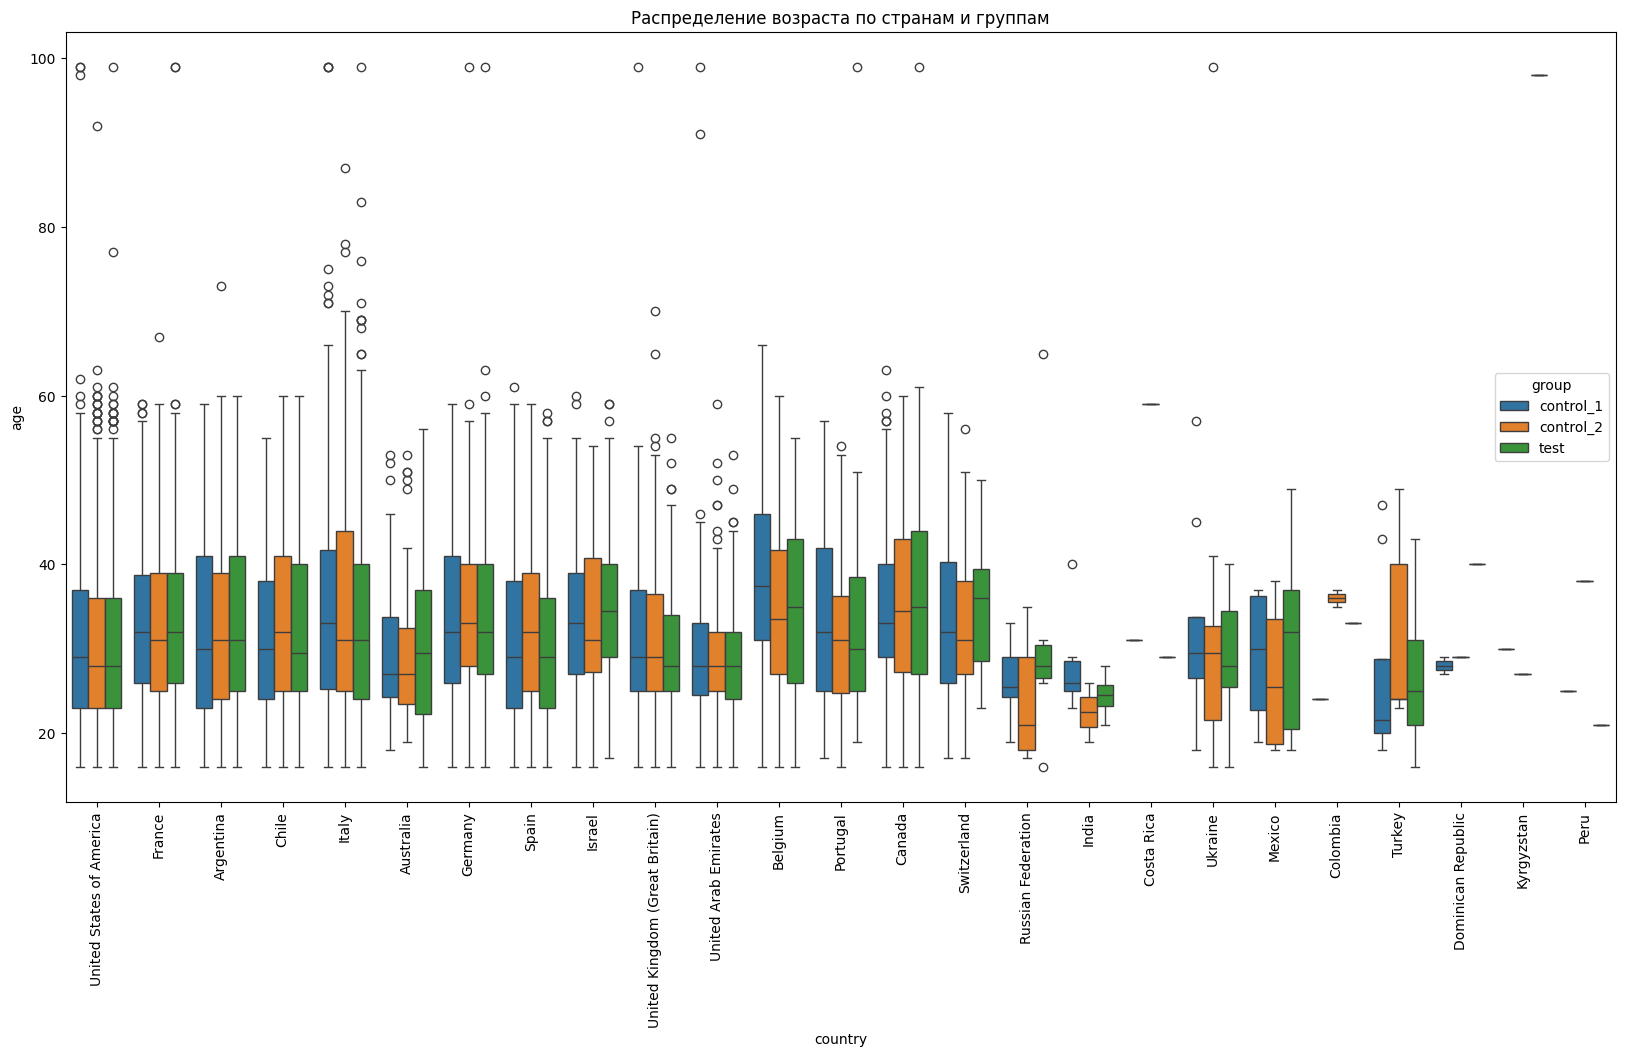

,Source,SS,DF,MS,F,p-unc,np2
0,country,4.723152e+04,24.0,1967.980115,19.510475,2.874253e-82,0.035417
1,group,6.977332e+01,2.0,34.886660,0.345865,7.076147e-01,0.000054
2,country * group,7.851789e+03,48.0,163.578931,1.621715,4.221763e-03,0.006067
3,Residual,1.286368e+06,12753.0,100.867871,NaN,NaN,NaN


In [13]:
#Попробуем посмотреть распределение возрастов по странам
plt.figure(figsize=(20, 10))
sns.boxplot(data=combined_users, x='country', y='age', hue='group')
plt.xticks(rotation=90)
plt.title('Распределение возраста по странам и группам')
plt.show()
#Визуально разница минимальна, за исключением некоторых стран с небольшими выборками.
pg.anova(data=combined_users, dv='age', between=['country', 'group']) #По группам возраст идентиЧен (0,7) , Отличия по стране/группе имеется, слабо выраженная. 
# Это мы наблюдаем и на графике - в некоторых странах есть различия по возрасту, но в больших группах различия минимальны. Сплитование по этой части тоже корректно

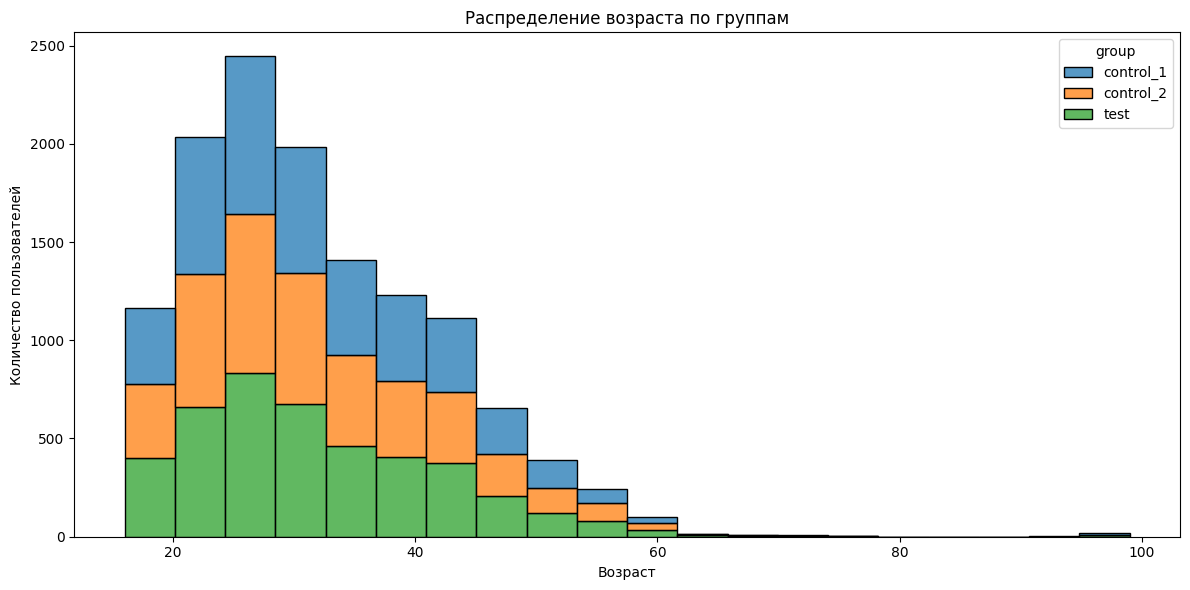

Levene test: LeveneResult(statistic=np.float64(0.27727147677955855), pvalue=np.float64(0.7578532736574778))
ANOVA: F_onewayResult(statistic=np.float64(0.3694512036723751), pvalue=np.float64(0.6911208622933104))


In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(data=combined_users, x='age', bins=20, hue='group', multiple='stack')
plt.title('Распределение возраста по группам')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()
# Разбиваем на списки age по группам
groups = combined_users.groupby('group')['age'].apply(list)

levene_result = stats.levene(*groups)
print("Levene test:", levene_result) # 0,75 Распределение идентично
anova_result = stats.f_oneway(*groups)
print("ANOVA:", anova_result) #0,69 - идентично

In [15]:
# Теперь посмотрим соотношение распределений по коэффициенту привлекательности - это может быть очень значимо с учетом специфики
pg.anova(data=combined_users.query("gender !=0"), dv='attraction_coeff', between='group')
#sns.histplot(data = combined_users.query("gender !=0"), x ='attraction_coeff' , bins=30, stat='density', common_norm=False, kde=True, alpha=0.4, hue = 'group')

#Сопоставимо. Отдельно проверил с фильтрацией по полу - также сплитование статистически не отличается. 0.71

,Source,ddof1,ddof2,F,p-unc,np2
0,group,2,12249,0.332581,0.717077,0.000054


Levene test: LeveneResult(statistic=np.float64(0.27727147677955855), pvalue=np.float64(0.7578532736574778))
ANOVA: F_onewayResult(statistic=np.float64(2.5413726633042173), pvalue=np.float64(0.08832048699483969))
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
control_1 control_2  -3.1365 0.9044 -20.8347 14.5616  False
control_1      test -15.5523 0.0956 -33.2505  2.1458  False
control_2      test -12.4158 0.2091 -29.8731  5.0415  False
-----------------------------------------------------------


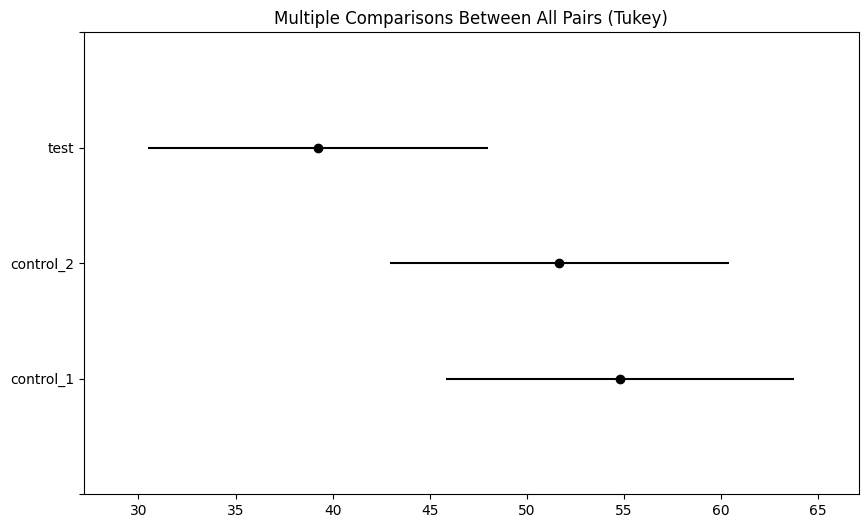

In [16]:
#Найдем самые платящие страны
prem_cntr_users = combined_users[(combined_users['is_premium'] != 0) | (combined_users['was_premium'] != 0)].groupby(['country', 'group']).agg({'is_premium': 'sum', 'was_premium': 'sum'}).sort_values(by = ['country', 'group', 'was_premium'], ascending = False)
#Каких-то серьезных выбросов между группами не наблюдается. Видим, что is|was особо не отличаются.

prem_cntr_users['left_perc'] = round(prem_cntr_users.is_premium/prem_cntr_users.was_premium*100,1)
prem_cntr_users = prem_cntr_users.reset_index()
prem_cntr_users.groupby('group')['left_perc'].mean().reset_index() #А вот тут серьезные различия, кстати. В контрольных группах 55-52% сохранились премиум, в тестовой - 39
groups_d = prem_cntr_users.groupby('group')['left_perc'].apply(list)

# Проверка гомогенности дисперсий — тест Левена
levene_resd = stats.levene(*groups)
print("Levene test:", levene_resd)

# Сравнение средних — ANOVA
anova_resd = stats.f_oneway(*groups_d)
print("ANOVA:", anova_resd)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Проведём Tukey 
tukey = pairwise_tukeyhsd(endog=prem_cntr_users['left_perc'],
                          groups=prem_cntr_users['group'],
                          alpha=0.05)

# Вывод результата
print(tukey)
tukey.plot_simultaneous()
plt.show()

#По итогу визуально фиксируем явное снижение доли премиум пользователей в тестовой группе, но стат. значимость не достигнута.

,Source,ddof1,ddof2,F,p-unc,np2
0,group,2,12825,0.538952,0.583372,0.000084


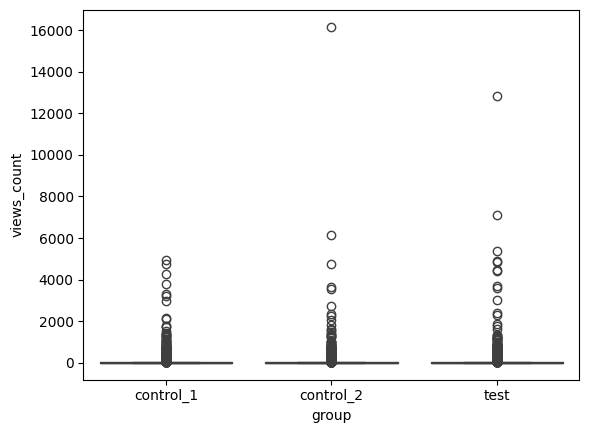

In [15]:
# Посмотрим по Views count - активность
sns.boxplot(data=combined_users, x='group', y='views_count')
pg.anova(data=combined_users, dv='views_count', between='group')
# Сопоставимо

---
### Выводы по сплитованию по Users:
- Сплитование по части пользователей полностью корректно.
- Промежуточный вывод - видим снижение соотношения кол-ва премиум пользователей в тестовой группе, но недостаточно стат. значимо, хотя визуально очень даже заметно.
- ---

#### Начинаем изучать транзакции


In [30]:
t_transactions['group'] = 'test'
c1_transactions['group'] = 'control_1'
c2_transactions['group'] = 'control_2'
combined_trans = pd.concat([t_transactions, c1_transactions, c2_transactions], ignore_index=True) #Объединяем
#Удаляем лишние страны
combined_trans  = combined_trans[~combined_trans['country'].isin(small_cntrs)] # 776
combined_trans.shape
# Ниже пришли к выводу, Что целесообразно отфильтровать выбросы (их 8). Поправка. После ревью решили разделить датасет на два - с фильтрацией и без.

# Также пришли к выводу, что стоит удалить 11 число каждого месяца, т.к. все транзакции за пределами октября и ноября выполнены строго в 11 число

trans_fin =combined_trans[combined_trans['paid_at'].dt.day != 11] #нефильтрованный по стоимости
trans_fin_filtered =  trans_fin[trans_fin['revenue']<40000] #Отфильтровали, в отдельный df, здесь разветвили
#Разница в df в 6 транзакциях. и 6 UID, все UID разные. 520 vs 514 транзакций

--- 
### 📌 Выводы по транзакциям

- 🔍 Обнаружены **аномальные платежи 11 числа каждого месяца**.  
  ➤ После удаления этих платежей, период транзакционной активности стал строго очерчен: **14.10.2017 – 15.11.2017**

- ⚠️ Выявлены **значительные выбросы** — транзакции выше **$4000**  
  ➤ Таких выбросов всего **6 штук**  
  ➤ Сделали 2 df: **С фильтрацией по транзакциям и без фильтрации**
  ➤ Дополнительно попробуем посчитать импакт этих транзакций

- 🌍 Были **удалены страны**, представленные **только в одной группе**,  
  ➤ Это искажало распределение и **нарушало корректность сплитования**

- 📉 После фильтрации:
  - Осталось **514 транзакций** по всем трём группам  
  - До фильтрации было **776 транзакций**
  - --- 

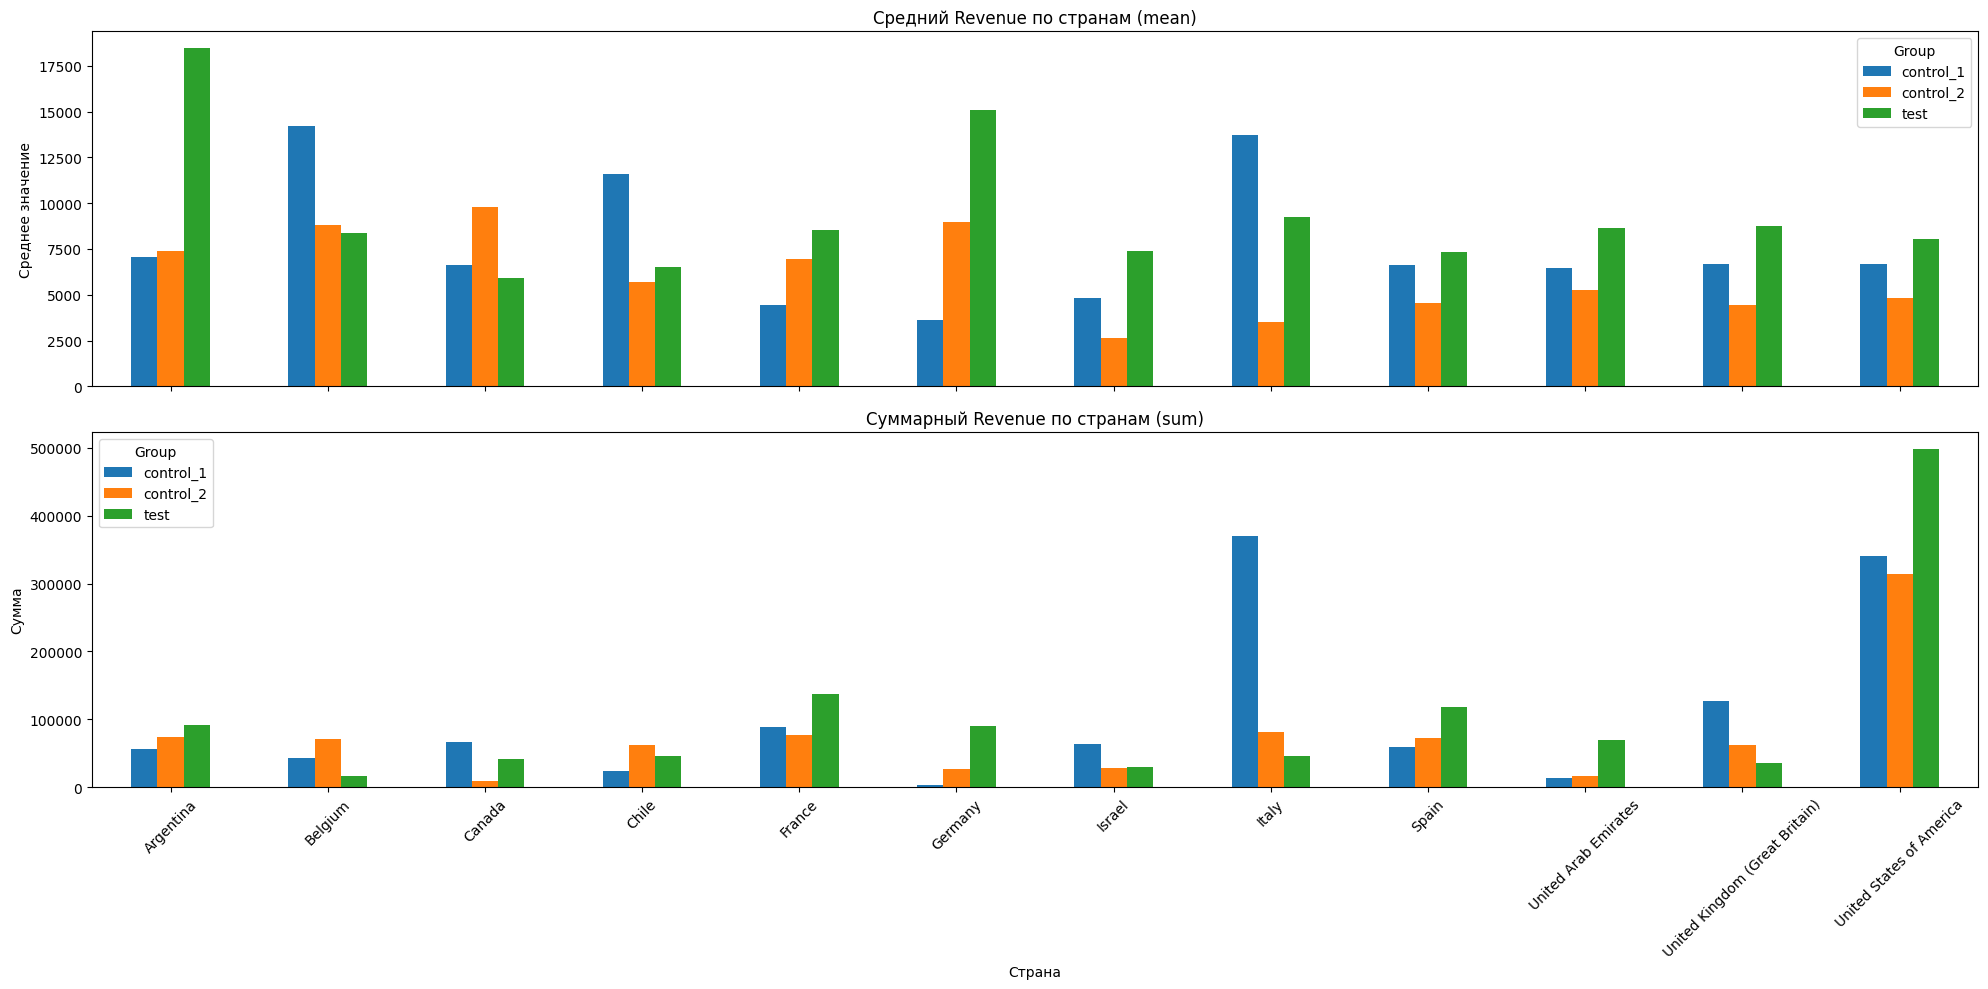

country,Argentina,Belgium,Canada,Chile,France,Germany,Israel,Italy,Spain,United Arab Emirates,United Kingdom (Great Britain),United States of America
group,,,,,,,,,,,,
control_1,56381.0,42588.0,66040.0,23244.0,88426.0,3601.0,62946.0,370201.0,59787.0,12883.0,126789.0,339833.0
control_2,73944.0,70681.0,9815.0,62712.0,76414.0,26949.0,28977.0,81198.0,72423.0,15808.0,62101.0,314756.0
test,92313.0,16744.0,41535.0,45708.0,136864.0,90441.0,29523.0,46345.0,117390.0,69147.0,34918.0,498082.0


In [73]:
ag = (
    trans_fin_filtered
    .groupby(['group', 'country'])['revenue']
    .agg(['mean', 'sum'])
    .round(1)
    .fillna(0)    
    .reset_index()
)
pivot_mean = ag.pivot_table(values='mean', index='group', columns='country')
pivot_sum = ag.pivot_table(values='sum', index='group', columns='country')
pivot_sum.fillna(0, inplace = True)
pivot_mean.fillna(0, inplace = True)
pivot_mean_w0 = pivot_mean.loc[:, ~(pivot_mean == 0).any()] #Тут у нас произошла фильтрация стран, по которым в какой-либо из выборок нулевое значение
pivot_sum_w0 = pivot_sum.loc[:, ~(pivot_sum == 0).any()]

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

# Первый график — средние значения
pivot_mean_w0.T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Средний Revenue по странам (mean)')
axes[0].set_ylabel('Среднее значение')
axes[0].legend(title='Group')

# Второй график — суммы
pivot_sum_w0.T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Суммарный Revenue по странам (sum)')
axes[1].set_ylabel('Сумма')
axes[1].set_xlabel('Страна')
axes[1].legend(title='Group')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
pivot_mean_w0
pivot_sum_w0

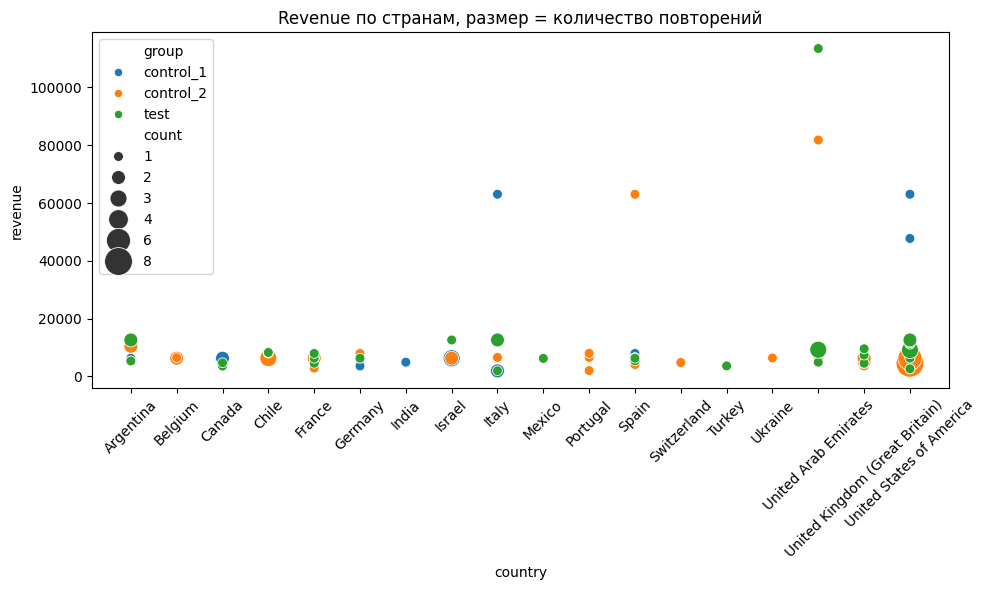

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,trans_month,period_join_paid,group
157,892038759.0,United Arab Emirates,2017-10-22 11:12:00,2017-10-22 16:23:00,113477.0,147.0,autoreply_message,premium_no_trial,2017-10,0 days 05:11:00,test
555,891778551.0,United Arab Emirates,2017-10-27 21:26:00,2017-10-27 22:30:00,81796.0,147.0,left_sidebar_menu,premium_no_trial,2017-10,0 days 01:04:00,control_2
437,892216461.0,United States of America,2017-10-18 14:41:00,2017-10-18 15:02:00,63037.0,147.0,autoreply_message,premium_no_trial,2017-10,0 days 00:21:00,control_1
333,892333905.0,Italy,2017-10-16 01:38:00,2017-10-16 13:10:00,63037.0,147.0,no_sympathy,premium_no_trial,2017-10,0 days 11:32:00,control_1
534,892307238.0,Spain,2017-10-16 16:01:00,2017-10-16 20:41:00,63037.0,147.0,left_sidebar_menu,premium_no_trial,2017-10,0 days 04:40:00,control_2
243,892421277.0,United States of America,2017-10-14 13:05:00,2017-10-15 13:11:00,47723.0,147.0,promo_09,premium_no_trial,2017-10,1 days 00:06:00,control_1


In [71]:
#trans_str['trans_month_str'] = trans_fin['trans_month'].astype(str)
#no_trial = combined_trans[combined_trans['product_type']=='premium_no_trial'] #255
counted = (
    trans_fin[(trans_fin['product_type']=='premium_no_trial')] #При общем подсчете по странам не особо информативно, хотя выше 30000 наблюдаются выбросы. Попробуем пройти по срезам
    .groupby(['country', 'group', 'revenue'])
    .size()
    .reset_index(name='count')
)
#С фильтрацией по premium no trial и по id платежа 147 наблюдаем явную тенденцию в таких странах как США, Чили, Италия - дороже платежи, меньше количество.
# НО! Это все с натяжкой, т.к. а) не могу объяснить разницу в стоимости, т.к. небольшой период, одна страна, вроде как подписка - почему? Может id - это не плат система?
#Если отфильтруем по trieal - то в США ситуация обратная - по стоимости выглядит сопоставимо, но по количеству тестовая группа сильно больше


# Рисуем scatterplot с размером точки по count
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=counted,
    x='country',
    y='revenue',
    hue='group',
    size='count',
    sizes=(50, 400)
)
plt.xticks(rotation=45)
plt.title('Revenue по странам, размер = количество повторений')
plt.tight_layout()
plt.show()

over_40000 = trans_fin[trans_fin['revenue']>40000].sort_values(by='revenue', ascending = False) #2 из ОАЭ, 2 из США

over_40000_uids = over_40000['uid'].tolist() #понадобится для фильтрации юзеров
over_40000

### Промежуточные выводы:

Ситуация не прояснилась, разве что явно видим выбросы. В целом, явно видно, что большинство значений менее 40000. Разница в 6 транзакций, каждая с уникальным UID, т.е., 6 пользователей. Изначально решили отрезать выбросы. после ревью решили провести анализ обоих датасетов, с выбросами и без.
Что мы видим на графике. Если  сфильтрацией по No Trial  - явно в тестовой группе стоимость выше в США, в Аргентине, в Израиле, в Италии. По осстальным - незначительно. 
При отсутствии фильтрации по продуктам, Италия выделяется контрольной группой 1. - и по цене, и по ревеню. 
Но мы не можем абсолютно точно установить, что в других странах эксперимент не проводился, т.к. я также не смог объяснить разницу в цене подписки в одних и тех же странах, даже с фильтрацией по одному и тому же платежному идентификатору. 

##### Визуальное сравнение выбросов
Без фильтрации выбросов - дорогих транзакций:

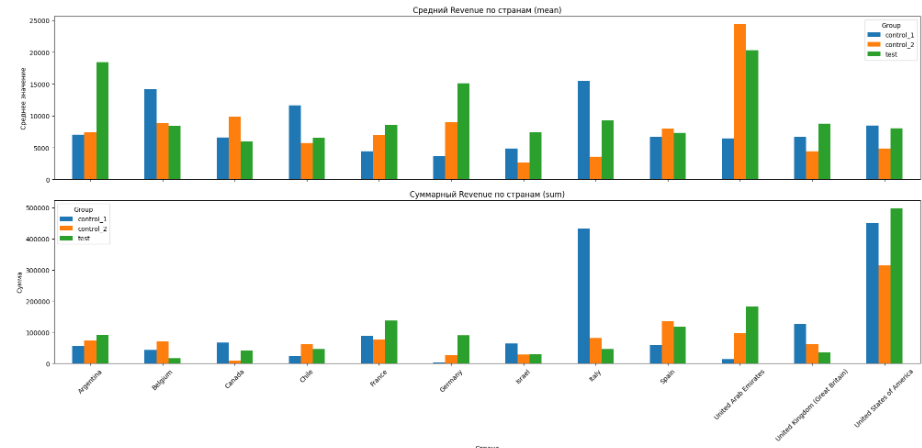


И с фильтрацией:


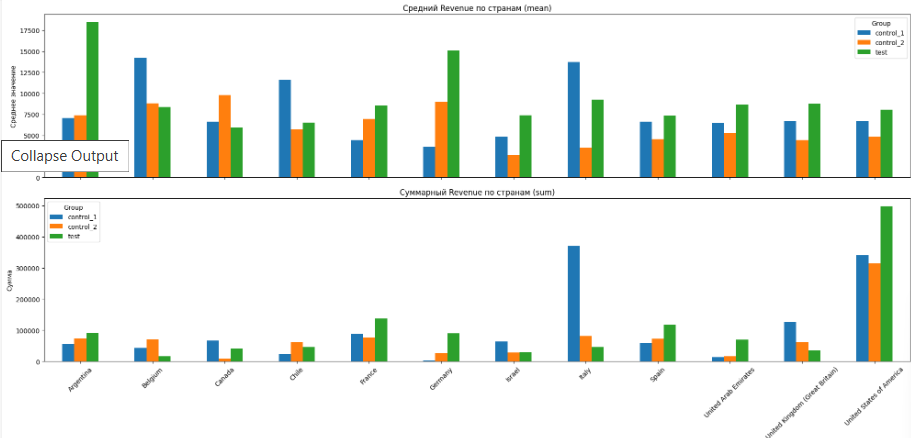




Визуально по США 2 выброса серьезно увеличивают суммарный revenue по 1 контрольной группе.
А по ОАЭ контрольная 2 и тестовая. На мой взгляд, выбросы очень сильно искажают картину даже в тех странах, где сравнительно крупная выборка, и, все же, транзакции можно бы удалить, т.к. допустим, юзеры и важны для бизнеса, но мы не удаляем все транзакции этих юзеров, мы удаляем только эти транзакции. Если бы в выборках было сколько-нибудь значительное количество транзакций подобного размера - они бы выбросами не являлись, а так они вредят тесту, даже несмотря на то, что у нас нет оснований считать их техническими ошибками.


##### Касаемо фильтрации по No Trial
Если в выборке оставить только No Trial, то остается 8 стран: США, Аргентина, ОАЭ, Франция, Израиль, Италия, Испания, Германия.
Если не фильтровать - то 12 стран. По остальным какая-то из групп содержит нулевые значения.
<u>Соображения были следующие:</u>
*Как будто бы, для чистоты эксперимента стоит оставить все виды продуктов, т.к. косвенно изменение цены подписки могло сподвигнуть на покупку других продуктов, что тоже существенно для бизнеса, и для наших метрик. Также не могу достоверно установить, является ли payment_id идентификатором платежной системы.
Например, для ОАЭ 0.0 - актуальный идентификатор, а 147 - нет. Для большинства самый популярный - 147. Отказываюсь от этой идеи, т.к. предположение
о происхождении идентификатора не могу подтвердить наглядно.
Оставляю все платежные идентификаторы.* 
Т.е., идея была следующая: ARPU по всем продуктам отражает общий бизнес-эффект. 

Однако, вероятно, я был неправ, т.к. это не отвечает целям проверки ключевых метрик именно с привязкой к продукту, иначе размывается эффект от изменений.
Итого, **тогда пересчитаем ARPPU|ARPU по No_trial, а расчет по всем продуктам также оставим в качестве Guardrail метрики**



In [101]:
'''
no_trial= combined_trans[combined_trans['product_type']=='premium_no_trial'] #255
no_trial_ag = no_trial.groupby(['country', 'group', 'payment_id'])['revenue'].mean().reset_index()
pd.pivot_table(no_trial_ag, values='revenue', index=['group', 'payment_id'], columns='country') #0.0 используется только по ОАЭ;147 - основной
no_trial.paid_at.min() #2017-01-11
no_trial.paid_at.max() #2017-12-11
no_trial.sort_values(by = 'paid_at') # Как-то подозрительно. И все еще понятия не имеем о периоде, и значения тестовой по стоимости выглядят неинформативно.
testing = no_trial[no_trial['paid_at'].dt.day != 11]
testing.groupby('trans_month').size() #внезапно остается только два месяца. и всего 155 транзакций. Попробуем теперь все тесты по этой выборке переделать
testing.max() # 2017-11-15 04:33:00
testing.min() #2017-10-14
'''
#Итого, в дальнейшем при тесте будем исходить из того, что нас интересует период 14.10 - 15.11. 1 Месяц. Перенесем эту фильтрацию на уровень выше

uid                         891130164.0
country                       Argentina
joined_at           2017-06-11 15:05:00
paid_at             2017-10-14 02:57:00
revenue                          1508.0
payment_id                          0.0
from_page             autoreply_message
product_type           premium_no_trial
trans_month                     2017-10
period_join_paid        0 days 00:02:00
group                         control_1
dtype: object

In [76]:
#Попробуем посчитать, какую долю от транзакций занимают топовые транзакции в совокупности. И по группам.

def top_share(df, frac=0.01):
    # доля выручки топ-1% транзакций по revenue
    n = max(1, int(len(df)*frac))
    top_rev = df.nlargest(n, 'revenue')['revenue'].sum()
    return top_rev / df['revenue'].sum()

# Общее и по группам
overall_top1 = top_share(trans_fin) #Меньше процента
by_group_top1 = trans_fin.groupby('group').apply(top_share).rename('top1_share')
by_group_top1
#влияние на группировки выбросы оказывают заметное (в тестовой наибольшее, 8% от всей выручки приходится на топ1% транзакций. Но, пожалуй, не определяющее.) 
#От контрольной 1 группы отличается в 2 раза.

group
control_1    0.042806
control_2    0.073280
test         0.083398
Name: top1_share, dtype: float64

In [70]:
#Еще тест, проверим, есть ли все пользователи в итоговой выборке transactions в группе users, перед переходом к расчету метрик
uids_trans = set(trans_fin['uid'])
uid_users = set(combined_users['uid'])
uids_only_in_trans = list(uids_trans - uid_users)
uids_only_in_trans #Пусто. Вот и славно. ETA завершили.

#Еще один шаг - мы отфильтровали основные страны нашего теста, где можно наблюдать более-менее результаты. Применим к нашему датасету эту фильтрацию
countries = list(pivot_mean_w0.columns)
trans_final = trans_fin[trans_fin['country'].isin(countries)] 
trans_final_filtered = trans_fin_filtered[trans_fin_filtered['country'].isin(countries)] #Параллельный df с фильтрацией по 40 000
users_final = combined_users[combined_users['country'].isin(countries)] 
#вот теперь данные готовы для расчета метрик и сравнений

#Отфильтруем аномальные UID с платежами в 11 число
excluded_uids = combined_trans[(combined_trans['revenue'] >= 40000)]['uid'].unique().tolist()
good_uids = set(trans_final['uid'].unique())
final_excluded_uids = [uid for uid in excluded_uids if uid not in good_uids]
users_final = users_final[~users_final['uid'].isin(final_excluded_uids)]
#А теперь создадим параллельный filtered df, из которого исключим 6 uid, которые имеют аномально большие транзакции, которые в scatterplot сильно оторваны от массы
trans_final_filtered[trans_final_filtered['uid'].isin(over_40000_uids)]['uid'].nunique() #А в отфильтрованном есть 4 из 6 uid. Т.е., uid с выбросами делали и обычные транзакции. Их оставим
nonunique_40000 = trans_final_filtered[trans_final_filtered['uid'].isin(over_40000_uids)]['uid'].unique().tolist()
users_final_filtered = users_final[~users_final['uid'].isin(list(set(over_40000_uids) - set(nonunique_40000)))]
users_final_filtered.shape #12136
users_final.shape #12138 - как и планировалось

(12138, 14)

Итого, к тестам подошли с датасетами:
trans_final, users_final
и
trans_final_filtered, users_final_filtered

Будем для них рассчитывать метрики параллельно, дабы отработать целесообразность фильтрации выбросов.

# 4. Выбор и расчёт ключевых метрик
**Основные метрики:**
1) Conversion to premium: доля пользователей, которые хоть раз оформили премиум
2) ARPU (Average Revenue Per User):
3) ARPPU (Average Revenue Per Paying User):
*retention не можем посчитать, т.к. период теста - 1 месяц, а периодичность оплаты подписки - тоже 1 месяц, нет смысла делать когортный анализ тоже


In [130]:
#Конверсия в премиум
#Здесь по-прежнему, отсутствие понимания сути продукта Premium_trial. Нет однозначного понимания, почему trial дороже, чем не trial. 
# Но все же, сравним по No Trial, т.к. декларируется, что именно в нем были изменения. И все же, отмечаем, что изменение стоимости здесь могло повлиять
# на другие продукты тоже.

#т.к. нам сравнивать несколько раз, упакуем в функцию.
def conv_rate(trans, users):
    no_trial_premium_uids = set(trans.query("product_type == 'premium_no_trial'")['uid'])
    tot_users = users.groupby('group')['uid'].nunique()
    converted_users = users[users['uid'].isin(no_trial_premium_uids)].groupby('group')['uid'].nunique()
    conversion_df = pd.DataFrame({'total': tot_users, 'converted': converted_users}).fillna(0)
    conversion_df['conversion_rate (%)'] = (conversion_df['converted'] / conversion_df['total'] * 100).round(2)
    return conversion_df

    

conversion_unfiltered = conv_rate(trans_final, users_final)
conversion_filtered = conv_rate(trans_final_filtered, users_final_filtered)
#Здесь, как и ожидалось, разницы почти нет, в контрол 1 на 3 чел, контрол 2 - 2 чел, тест - 1 чел. в conversion rate различия также незначительные.
#Видно, что в тестовой конверсия меньше. выборки больше 30
conversion_filtered.loc[['control_1', 'test'], 'conversion_rate (%)']

group
control_1    1.10
test         0.87
Name: conversion_rate (%), dtype: float64

conversion_unfiltered

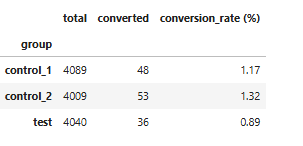

conversion_filtered

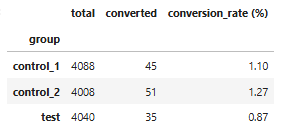

In [192]:
#ARPU и ARPPU
#Считаем по Premium_No_Trial (pnt)
def arpu_pnt(trans, users):
    pnt = trans.query("product_type == 'premium_no_trial'")
    total_users = users.groupby('group')['uid'].nunique()
    # Число платящих пользователей по группам
    paying_users = pnt.groupby('group')['uid'].nunique()
    # Суммарный доход по группам
    total_revenue = pnt.groupby('group')['revenue'].sum()
    # ARPU = общая выручка / общее число пользователей
    arpu = (total_revenue / total_users).round(2)
    # ARPPU = общая выручка / число платящих пользователей
    arppu = (total_revenue / paying_users).round(2)
    arpu_df = pd.DataFrame({
        'Total Users': total_users,
        'Paying Users': paying_users,
        'Total Revenue': total_revenue,
        'ARPU': arpu,
        'ARPPU': arppu}).fillna(0)
    max_arppu = arpu_df['ARPPU'].max()
    max_arpu = arpu_df['ARPU'].max()
    arpu_df['ARPPU_diff'] = round(((arpu_df['ARPPU'] - max_arppu) / max_arppu * 100),2)
    arpu_df['ARPU_diff'] = round(((arpu_df['ARPU'] - max_arpu) / max_arpu * 100),2)
    return arpu_df

arpu_unfiltered = arpu_pnt(trans_final, users_final)
arpu_filtered = arpu_pnt(trans_final_filtered, users_final_filtered)

#И в качестве guardrail сделаем расчет arpu total без фильтрации по pnt, т.е., по всем транзакциям без исключения.
def arpu_total(trans, users):
    total_users = users.groupby('group')['uid'].nunique()
    # Число платящих пользователей по группам
    paying_users = trans.groupby('group')['uid'].nunique()
    # Суммарный доход по группам
    total_revenue = trans.groupby('group')['revenue'].sum()
    # ARPU = общая выручка / общее число пользователей
    arpu = (total_revenue / total_users).round(2)
    # ARPPU = общая выручка / число платящих пользователей
    arppu = (total_revenue / paying_users).round(2)
    arpu_df = pd.DataFrame({
        'Total Users': total_users,
        'Paying Users': paying_users,
        'Total Revenue': total_revenue,
        'ARPU': arpu,
        'ARPPU': arppu}).fillna(0)
    max_arppu = arpu_df['ARPPU'].max()
    max_arpu = arpu_df['ARPU'].max()
    arpu_df['ARPPU_diff'] = round(((arpu_df['ARPPU'] - max_arppu) / max_arppu * 100),2)
    arpu_df['ARPU_diff'] = round(((arpu_df['ARPU'] - max_arpu) / max_arpu * 100),2)
    return arpu_df

arpu_unfiltered_total = arpu_total(trans_final, users_final)
arpu_filtered_total = arpu_total(trans_final_filtered, users_final_filtered)

In [201]:
def compare_before_after(before_df, after_df):
    df = before_df[['ARPU', 'ARPPU', 'Total Revenue']].copy()
    df.columns = ['ARPU_before', 'ARPPU_before', 'Revenue_before']
    df['ARPU_after'] = after_df['ARPU']
    df['ARPPU_after'] = after_df['ARPPU']
    df['ARPU_diff_abs'] = (df['ARPU_after'] - df['ARPU_before']).round(2)
    df['ARPU_diff_%'] = ((df['ARPU_after'] / df['ARPU_before'] - 1) * 100).round(2)

    df['ARPPU_diff_abs'] = (df['ARPPU_after'] - df['ARPPU_before']).round(2)
    df['ARPPU_diff_%'] = ((df['ARPPU_after'] / df['ARPPU_before'] - 1) * 100).round(2)
    return df

impact_no_trial = compare_before_after(arpu_unfiltered, arpu_filtered)
impact_total = compare_before_after(arpu_unfiltered_total, arpu_filtered_total)

impact_no_trial 

#Импакт выбросов меньше выражен на тестовой группе, и сильнее на контрольных. В итоге, после фильтрации выбросов данные по тестовой группе выглядят ближе к 
#к данным контрольных групп. а ARPPU выглядит еще более значимым в сравнении с контрольными

,ARPU_before,ARPPU_before,Revenue_before,ARPU_after,ARPPU_after,ARPU_diff_abs,ARPU_diff_%,ARPPU_diff_abs,ARPPU_diff_%
group,,,,,,,,,
control_1,103.83,8844.88,424554.0,61.34,5572.38,-42.49,-40.92,-3272.50,-37.00
control_2,115.05,8702.89,461253.0,78.95,6204.31,-36.10,-31.38,-2498.58,-28.71
test,105.50,11839.39,426218.0,77.41,8935.46,-28.09,-26.63,-2903.93,-24.53


#### ARPU|ARPPU No_trial - основной тестовый показатель

Без фильтрации


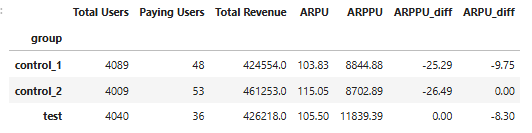



С фильтрацией


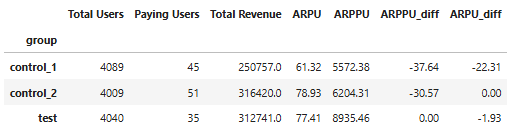




#### ARPU|ARPPU total - По всем пользователям (как guardrail метрика)

Без фильтрации

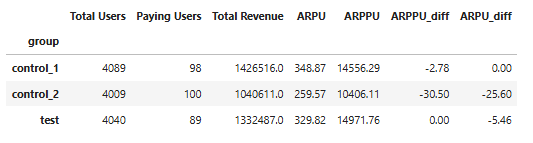


С фильтрацией

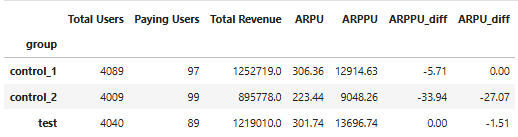



#### Предварительные выводы 
*По итогам расчета метрик*

- Крупные выбросы (> $40 000) оказывают значимое влияние на итоговые значения ARPU/ARPPU, особенно в тестовой группе.
- Различия в ARPPU предсказуемо в пользу тестовой в обоих случаях. Без фильтрации ARPPU в тестовой группе (test) был очень высоким (13 989), но это, скорее всего, из-за нескольких крупных транзакций-выбросов.
- Различия между группами более выражены у датасета с фильтрацией
-  С фильтрацией данные меняются и динамика иная - провал в тестовой группе менее выражен. С фильтрацией разрыв в ARPU c с наилучшим показателем у второй группы -1 %, т.е. эффект выбросов почти полностью маскировал реальную картину.
- В целом, по ARPU по-прежнему тестовая группа не демонстрирует какой-либо заметной динамики, и далее явно можно предположить, что по итогам тестов статзначимости тут не будет.

###### По результатам сравнения с guardrail
По premium no trial фильтрация выбросов серьёзно сдвигает значения ARPU и ARPPU, но в тестовой группе динамика по сравнению с контролем остаётся примерно такой же. Это подтверждает, что влияние изменения цены на поведение именно в этой группе незначительное.
Перестановка control_1 и control_2 по ARPU, но отсутствует динамика по тестовой группе - она такая же. Это не позволяет сделать предположение о перераспределении пользовательской активности в сторону других продуктов. - тогда бы цифры по ARPU оказались значительно выше в тестовой группе по всем пользователям в сравнении с данными по no trial пользователями.
В сухом остатке — импакт изменения цены в рамках этого периода теста минимальный и, скорее всего, не компенсирует снижение конверсии в премиум.

In [108]:
# А что будет если просто посчитать метрики по юзерам, насколько будет отличаться?

grouped = users_final.groupby('group')
total_users = grouped['uid'].nunique()
paying_users = grouped.apply(lambda x: (x['total_revenue'] > 0).sum())
total_revenue = grouped['total_revenue'].sum()
arpu = (total_revenue / total_users).round(2)
arppu = (total_revenue / paying_users).round(2)
conversion_rate = ((paying_users / total_users) * 100).round(2)
metrics_df = pd.DataFrame({
    'Total Users': total_users,
    'Paying Users': paying_users,
    'Total Revenue': total_revenue,
    'ARPU': arpu,
    'ARPPU': arppu,
    'Conversion Rate (%)': conversion_rate
})
metrics_df

#Тенденции похожие, цифры другие. в целом, ожидаемо, т.к., а) часть пользователей были ранее отфильтрованы из транзакций, б) могут быть неучтенные из других периодов
#Будем использовать все-таки тот, что на основе транзакций.

,Total Users,Paying Users,Total Revenue,ARPU,ARPPU,Conversion Rate (%)
group,,,,,,
control_1,4089,178,2427633,593.70,13638.39,4.35
control_2,4009,172,1770379,441.60,10292.90,4.29
test,4040,139,2240485,554.58,16118.60,3.44


# 5. Статистический анализ и сравнение метрик
5.1. Для conversion rate - z test

5.2. Для ARPU/ARPU - сравним с фильтрацией/без фильтрации; сперва будем сравнивать по NoTrial, далее также сравним по всем продуктам (т.к. выше решили, что оставим для guardrail метрики) Используем ANOVA

5.3. Также пересчитаем Краскал-Уоллеса, рассчитав ревеню для каждого пользователя и получив выборку. Ошибка была в том, что Краскал_Уоллес не сравнивает средние/медианы, но сравнивает распределения рангов, соответствующих ревеню пользователей. Рассортировали пользователей по ревеню по рангам и сравнили, насколько в каждой из трех выборок они отличаются.




### 5.1. Z-test для Конверсии
--- 

In [134]:
def z_tests (df):
    #Пара Control1 и Test
    suc1 = df.loc[['control_1', 'test'], 'converted'].values.astype(int)
    nobs1 = df.loc[['control_1', 'test'], 'total'].values.astype(int)
    z_stat1, p_val1 = proportions_ztest(suc1, nobs1)
    #Пара Control2 и Test
    suc2 = df.loc[['control_2', 'test'], 'converted'].values.astype(int)
    nobs2 = df.loc[['control_2', 'test'], 'total'].values.astype(int)
    z_stat2, p_val2 = proportions_ztest(suc2, nobs2)
    return  z_stat1, p_val1,  z_stat2, p_val2

#для conversion_unfiltered
unf_z_stat1, unf_p_val1, unf_z_stat2, unf_p_val2= z_tests(conversion_unfiltered)
unfiltered_conversion_test = pd.DataFrame({
    'Pairs': ['Control_1 vs Test', 'Control_2 vs Test'],
    'Conv_rate' :[f"{conversion_unfiltered.loc['control_1', 'conversion_rate (%)']} % vs {conversion_unfiltered.loc['test', 'conversion_rate (%)']} %",
    f"{conversion_unfiltered.loc['control_2', 'conversion_rate (%)']} % vs {conversion_unfiltered.loc['test', 'conversion_rate (%)']} %"],
    'Z_stat' : [unf_z_stat1, unf_z_stat2],
    'P_value':[unf_p_val1, unf_p_val2]
})
#для conversion_filtered
f_z_stat1, f_p_val1, f_z_stat2, f_p_val2= z_tests(conversion_filtered)
filtered_conversion_test = pd.DataFrame({
    'Pairs': ['Control_1 vs Test', 'Control_2 vs Test'],
    'Conv_rate' :[f"{conversion_filtered.loc['control_1', 'conversion_rate (%)']} % vs {conversion_filtered.loc['test', 'conversion_rate (%)']} %",
    f"{conversion_filtered.loc['control_2', 'conversion_rate (%)']} % vs {conversion_filtered.loc['test', 'conversion_rate (%)']} %"],
    'Z_stat' : [f_z_stat1, f_z_stat2],
    'P_value':[f_p_val1, f_p_val2]
})
unfiltered_conversion_test

,Pairs,Conv_rate,Z_stat,P_value
0,Control_1 vs Test,1.17 % vs 0.89 %,1.260615,0.207448
1,Control_2 vs Test,1.32 % vs 0.89 %,1.848593,0.064517


##### unfiltered_conversion_test

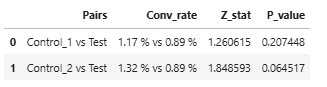

##### filtered_conversion_test

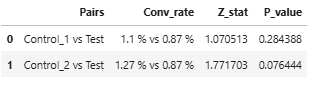

Итого наглядно видно, что в обоих случаях, и при фильтрации, и при ее отсутствии не получилось отвергнуть H0 - статистически значимая разница отсутствует, p-value в обоих случаях выше 0,05. В сравнении со второй контрольной группой результат близок к стат. 
значимому, но все-таки нет. Увеличение выборки, возможно, показало бы ее наличие. Но это предположение. Искуственно увеличивать выборку бутстрапом смысла не вижу.
Тем не менее, конверсия в тестовой группе ощутимо выше. 
Выбросы не влияют на результаты (ну в случае конверсии это и не удивительно, т.к. важно количество конвертированных, а выбросы распределены равномерно между группами)

### 5.2. Тесты для ARPU|ARPPU
#### Для No_Trial
- Раздельно для фильтрованного и нефильтрованного датасета проведем проверки гомоскедастичности и дисперсии, и далее проведем ANOVA
- После этого сформируем датасет под Краскал-Уоллеса и проведем тест
#### Для Общего
- Раздельно для фильтрованного и нефильтрованного датасета проведем проверки гомоскедастичности и дисперсии, и далее проведем ANOVA
- После этого сформируем датасет под Краскал-Уоллеса и проведем тест

Далее сравним

#### Подготовка датасетов
---


,W,pval,equal_var
levene,5.123319,0.007237,False


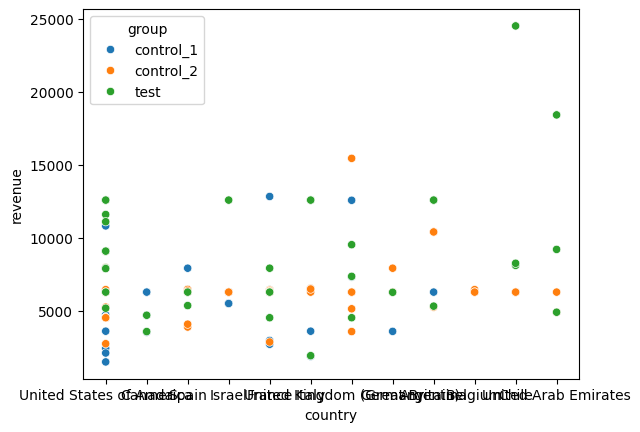

In [166]:
#Сперва примержимданные из trans к users
def mrg(trans, users):
    revenue_p_user = trans.groupby('uid')['revenue'].sum().reset_index()
    merged_users = users.merge(revenue_p_user, on='uid', how='left')
    merged_users['revenue'] = merged_users['revenue'].fillna(0)
    return merged_users
#По No_trial 
pnt_trans = trans_final.query("product_type == 'premium_no_trial'")
pnt_trans_filtered = trans_final_filtered.query("product_type == 'premium_no_trial'")
pnt_merged_users = mrg(pnt_trans, users_final)  
pnt_merged_users_filtered = mrg(pnt_trans_filtered, users_final_filtered)

#По всем
all_merged_users = mrg(trans_final, users_final)  
all_merged_users_filtered = mrg(trans_final_filtered, users_final_filtered)

#СОбрали 4 датасета. Теперь проверки
def checks(datasets):
    results = []
    for i, df in enumerate(datasets, start=1):
        norm_res = pg.normality(df, group='group', dv='revenue')
        homo_res = pg.homoscedasticity(data=df, dv='revenue', group='group')
        
        results.append({
            'Dataset': f'df_{i}',
            'Normality_p': norm_res['pval'].min(),  # можно брать min по группам
            'Normality_pass': norm_res['pval'].min() > 0.05,
            'Homoscedasticity_p': homo_res['pval'].item(),
            'Homoscedasticity_pass': homo_res['pval'].item() > 0.05
        })
    
    return pd.DataFrame(results)
checks([all_merged_users, all_merged_users_filtered, pnt_merged_users_filtered, pnt_merged_users])
all_merged_users.revenue.sum() # 3799614.0
all_merged_users_filtered.revenue.sum()  #3367507
pnt_merged_users_filtered.revenue.sum() #879918
pnt_merged_users.revenue.sum() # 1312025

#Теперь для ARPPU
pnt_merged_users_ppu = pnt_merged_users.query("revenue > 0")
pnt_merged_users_filtered_ppu = pnt_merged_users_filtered.query("revenue > 0")
all_merged_users_ppu = all_merged_users.query("revenue > 0")
all_merged_users_filtered_ppu = all_merged_users_filtered.query("revenue > 0")
checks([all_merged_users_ppu, all_merged_users_filtered_ppu, pnt_merged_users_filtered_ppu, pnt_merged_users_ppu])
pnt_merged_users_filtered_ppu.shape #131
sns.scatterplot(
    data=pnt_merged_users_filtered_ppu,
    x='country',
    y='revenue',
    hue='group')
#Проверим с логарифмированием единственный из 8 датасет, где отсутствует гомоскедастичность
def homo_log(df):
    df_log = df.copy()
    df_log['revenue'] = np.log1p(df_log['revenue'])
    return pg.homoscedasticity(data=df_log, dv='revenue', group='group')
homo_log(pnt_merged_users_filtered_ppu)
#Ну что ж, непараметрический тест значит

Результаты проверок:

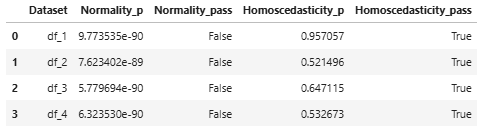

Во всех случаях распределение ненормально (что ожидаемо), но гомоскедастично. Как мы помним, у нас везде выборки более 30, так что в соответствии с ЦПТ можно проводить ANOVA и попарные т-тесты

Датасеты для ARPPU

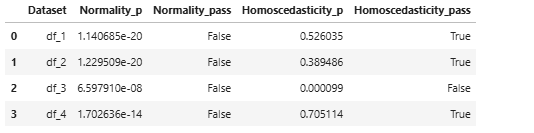

А вот тут у нас внезапно гомоскедастичность по pnt с фильтрованными выбросами отвалилась. Что странно, кстати, я думал, фильтрация выбросов наоборот повышает ее. Логарифмирование тоже не спасло. Значит для него точно остается только непараметрика.

#### Переходим к тестам
---


In [178]:
#ARPU тесты - ANOVA и попарный ТТ
pg.anova(data=pnt_merged_users, dv='revenue', between='group') 
pg.pairwise_ttests(data=pnt_merged_users, dv='revenue', between='group', padjust='bonf') 
pg.anova(data=pnt_merged_users_filtered, dv='revenue', between='group') 
pg.pairwise_ttests(data=pnt_merged_users_filtered, dv='revenue', between='group', padjust='bonf') 
pg.anova(data=all_merged_users, dv='revenue', between='group') 
pg.pairwise_ttests(data=all_merged_users, dv='revenue', between='group', padjust='bonf') 

pg.anova(data=all_merged_users_filtered, dv='revenue', between='group') 
pg.pairwise_ttests(data=all_merged_users_filtered, dv='revenue', between='group', padjust='bonf') 

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,group,control_1,control_2,False,True,0.904967,4773.945229,two-sided,0.365529,1.00000,bonf,0.038,0.019947
1,group,control_1,test,False,True,0.048279,5837.001789,two-sided,0.961496,1.00000,bonf,0.025,0.001067
2,group,control_2,test,False,True,-1.596504,6692.928700,two-sided,0.110423,0.33127,bonf,0.09,-0.035525


### Результаты
#### Для значений ARPU без фильтрации 6 выбросов, только по продукту PNT:
ANOVA

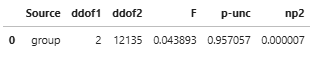

TT
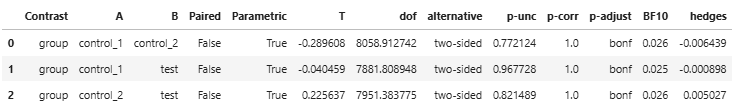
ANOVA и TT не показали стат значимость ни в одной группе, выборки стремятся к единице, т.е., средние практически идентичны
По сути, группы по ARPU ведут себя практически одинаково.

#### Для значений ARPU с фильтрацией 6 выбросов, только по продукту PNT:
ANOVA
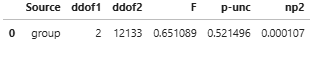

TT
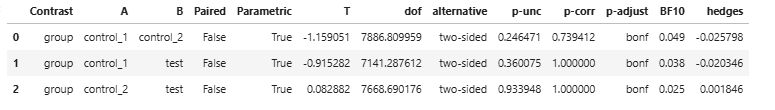

Различия выше, однако до ст. значимости сильно не дотягивает. Не можем отвергнуть Н0 ни в одной из пар

#### Для значений ARPU без фильтрации 6 выбросов, по всем продуктам:

ANOVA

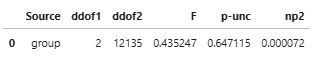

TT
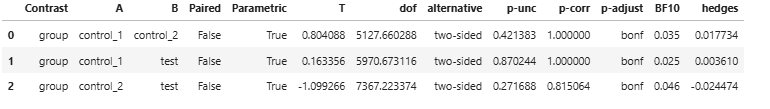

Аналогичные результаты, что и по продукту PNT. Это говорит о том, что повышение стоимости в одной категории существенно не повлияло на показатели выручки, в т.ч., и по остальным продуктам, по крайней мере, за тестовый период. Отсутствуют стат. значимые изменения


#### Для значений ARPU с фильтрацией 6 выбросов, по всем продуктам:
ANOVA 
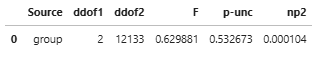

TT
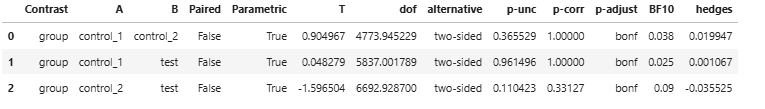

В случае фильтрации более-менее близкий результат к стат. значимому в тестовой по сравнении со второй, но все же выше o.5, соответственно, стат. значимым не является. К тому же, в сравнении с контрольной 1 стремится к идентичности. 

Таким образом, изменения в стоимости PNT продукта в нескольких плат системах в нескольких странах существенно не повлияли за месяц на размер выручки на пользователя

In [ ]:
pnt_merged_users_ppu = pnt_merged_users.query("revenue > 0")
pnt_merged_users_filtered_ppu = pnt_merged_users_filtered.query("revenue > 0")
all_merged_users_ppu = all_merged_users.query("revenue > 0")
all_merged_users_filtered_ppu = all_merged_users_filtered.query("revenue > 0")

In [186]:
#Тесты для ARPPU
#ARPU тесты - ANOVA и попарныы ТТ
pg.anova(data=pnt_merged_users_ppu, dv='revenue', between='group') 
pg.pairwise_ttests(data=pnt_merged_users_ppu, dv='revenue', between='group', padjust='bonf') 
pg.anova(data=pnt_merged_users_filtered_ppu, dv='revenue', between='group') #Помним,что нерелевантно, ибо не гомоскедастично
pg.pairwise_ttests(data=pnt_merged_users_filtered_ppu, dv='revenue', between='group', padjust='bonf') #Помним,что нерелевантно, ибо не гомоскедастично
pg.anova(data=all_merged_users_ppu, dv='revenue', between='group') 
pg.pairwise_ttests(data=all_merged_users_ppu, dv='revenue', between='group', padjust='bonf')
pg.anova(data=all_merged_users_filtered_ppu, dv='revenue', between='group') 
pg.pairwise_ttests(data=all_merged_users_filtered_ppu, dv='revenue', between='group', padjust='bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,group,control_1,control_2,False,True,1.094935,100.269136,two-sided,0.276168,0.828505,bonf,0.272,0.157357
1,group,control_1,test,False,True,-0.210925,119.862123,two-sided,0.833304,1.000000,bonf,0.163,-0.029797
2,group,control_2,test,False,True,-3.442876,118.215782,two-sided,0.000797,0.002390,bonf,35.534,-0.519281


### Результаты
#### Для значений ARPPU без фильтрации 6 выбросов, только по продукту PNT:
ANOVA
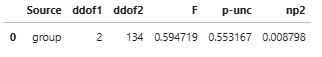


TT
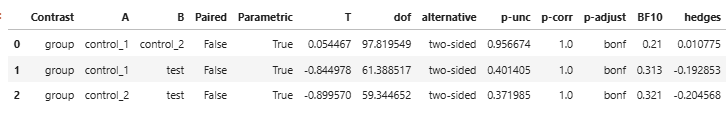
Отсутствует стат значимость

#### Для значений ARPPU с фильтрацией 6 выбросов, только по продукту PNT:
ANOVA
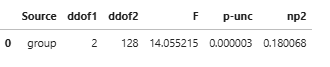

TT
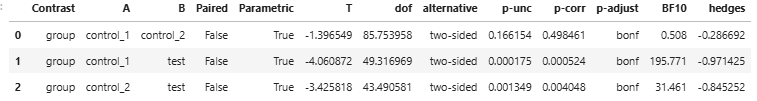
**не вполне надежный результат, т.к. негомоскедастичный датасет*
Удаление выбросов позволило увидеть стат значимый результат. Различия между тестовой в сравнении с обеими контрольными группами стат значимы, тогда как АА сравнение стат значимости не показывает. Сама по себе метрика ARPPU не столь важна, как ARPU, и в целом, результат логичный, для бизнеса, как будто бы, не столь значим, но подтверждает, что тест сработал с технической точки зрения (т.е., повышение стоимости фактически привело к тому, что приобретенные подписки были дороже)

#### Для значений ARPPU без фильтрации 6 выбросов, по всем продуктам:


ANOVA

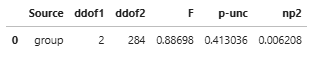

TT

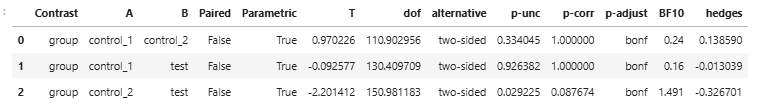

Не зафиксирована стат. значимость


#### Для значений ARPPU с фильтрацией 6 выбросов, по всем продуктам:
ANOVA 

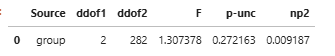

TT

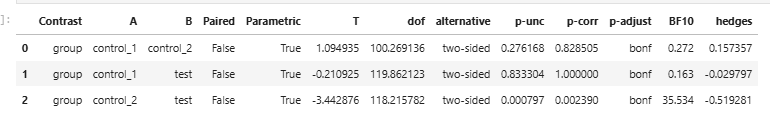

Стат значимо различие между тестовой и Контрольной 2. Но ANOVA не зафиксировала.
---

В целом, наиболее интересно ARPPU по PNT с фильтрацией выбросов, но ее стоит пересчитать непараметрическим тестом

In [110]:
#Краскал по нефильтрованным всем значениям
from scipy.stats import kruskal

user_revenue = trans_final.groupby(['group', 'uid'])['revenue'].sum().reset_index()
all_users = users_final[['group', 'uid']].drop_duplicates()
user_revenue = all_users.merge(user_revenue, on=['group', 'uid'], how='left').fillna({'revenue': 0})
arpu_values = [user_revenue.query("group == @g")['revenue'] for g in user_revenue['group'].unique()]
# Kruskal–Wallis для ARPU
stat_arpu, p_arpu = kruskal(*arpu_values)
print(f"ARPU — H-stat: {stat_arpu:.3f}, p-value: {p_arpu:.4f}")

# ARPPU (только платившие)
arppu_values = [user_revenue.query("group == @g and revenue > 0")['revenue'] 
    for g in user_revenue['group'].unique()
]

# Kruskal–Wallis для ARPPU
stat_arppu, p_arppu = kruskal(*arppu_values)
print(f"ARPPU — H-stat: {stat_arppu:.3f}, p-value: {p_arppu:.4f}")


#Итого, подтверждает наши наблюдения. Отсутствует стат. значимые различия по ARPU, но имеются по ARPPU, что логично, т.к. напрямую дороже подписки.

ARPU — H-stat: 0.677, p-value: 0.7129
ARPPU — H-stat: 16.592, p-value: 0.0002


In [203]:
#Краскал по фильтрованным всем значениям
user_revenue_f = trans_final_filtered.groupby(['group', 'uid'])['revenue'].sum().reset_index()
all_users_f = users_final_filtered[['group', 'uid']].drop_duplicates()
user_revenue_f = all_users_f.merge(user_revenue_f, on=['group', 'uid'], how='left').fillna({'revenue': 0})
arpu_values_f = [user_revenue_f.query("group == @g")['revenue'] for g in user_revenue_f['group'].unique()]
# Kruskal–Wallis для ARPU
stat_arpu_f, p_arpu_f = kruskal(*arpu_values_f)
print(f"ARPU — H-stat: {stat_arpu_f:.3f}, p-value: {p_arpu_f:.4f}")

# ARPPU (только платившие)
arppu_values_f = [user_revenue_f.query("group == @g and revenue > 0")['revenue'] 
    for g in user_revenue_f['group'].unique()
]

# Kruskal–Wallis для ARPPU
stat_arppu_f, p_arppu_f = kruskal(*arppu_values_f)
print(f"ARPPU — H-stat: {stat_arppu_f:.3f}, p-value: {p_arppu_f:.4f}")

#Итого, подтверждает наши наблюдения. Отсутствует стат. значимые различия по ARPU, но имеются по ARPPU, что логично, т.к. напрямую дороже подписки.

ARPU — H-stat: 0.556, p-value: 0.7572
ARPPU — H-stat: 18.700, p-value: 0.0001


In [204]:
# Краскал по PNT данным.
#Без фильтрации
pnt = trans_final.query("product_type == 'premium_no_trial'")

# ARPU — все пользователи
pnt_user_revenue = pnt.groupby(['group', 'uid'])['revenue'].sum().reset_index()
pnt_all_users = users_final[['group', 'uid']].drop_duplicates()
pnt_user_revenue = pnt_all_users.merge(pnt_user_revenue, on=['group', 'uid'], how='left').fillna({'revenue': 0})

pnt_arpu_values = [pnt_user_revenue.query("group == @g")['revenue'] 
                   for g in pnt_user_revenue['group'].unique()]
stat_pnt_arpu, p_pnt_arpu = kruskal(*pnt_arpu_values)
print(f"PNT ARPU — H-stat: {stat_pnt_arpu:.3f}, p-value: {p_pnt_arpu:.4f}")

# ARPPU — только платившие
pnt_arppu_values = [pnt_user_revenue.query("group == @g and revenue > 0")['revenue'] 
                    for g in pnt_user_revenue['group'].unique()]
stat_pnt_arppu, p_pnt_arppu = kruskal(*pnt_arppu_values)
print(f"PNT ARPPU — H-stat: {stat_pnt_arppu:.3f}, p-value: {p_pnt_arppu:.4f}")


#Все еще аналогичные данные. ARPPU - стат значимые различия, ARPU - нет

PNT ARPU — H-stat: 3.396, p-value: 0.1831
PNT ARPPU — H-stat: 12.844, p-value: 0.0016


In [205]:
# Фильтрованные данные
pnt_f = trans_final_filtered.query("product_type == 'premium_no_trial'")
# ARPU — все пользователи
pnt_user_revenue_f = pnt_f.groupby(['group', 'uid'])['revenue'].sum().reset_index()
pnt_all_users_f = users_final_filtered[['group', 'uid']].drop_duplicates()
pnt_user_revenue_f = pnt_all_users_f.merge(pnt_user_revenue_f, on=['group', 'uid'], how='left').fillna({'revenue': 0})

pnt_arpu_values_f = [pnt_user_revenue_f.query("group == @g")['revenue'] 
                     for g in pnt_user_revenue_f['group'].unique()]
stat_pnt_arpu_f, p_pnt_arpu_f = kruskal(*pnt_arpu_values_f)
print(f"PNT ARPU (filtered) — H-stat: {stat_pnt_arpu_f:.3f}, p-value: {p_pnt_arpu_f:.4f}")

# ARPPU — только платившие
pnt_arppu_values_f = [pnt_user_revenue_f.query("group == @g and revenue > 0")['revenue'] 
                      for g in pnt_user_revenue_f['group'].unique()]
stat_pnt_arppu_f, p_pnt_arppu_f = kruskal(*pnt_arppu_values_f)
print(f"PNT ARPPU (filtered) — H-stat: {stat_pnt_arppu_f:.3f}, p-value: {p_pnt_arppu_f:.4f}")

#Аналогично

PNT ARPU (filtered) — H-stat: 3.073, p-value: 0.2151
PNT ARPPU (filtered) — H-stat: 16.639, p-value: 0.0002


### Выводы по результатам непараметрических тестов
#### 1. ARPU 
ANOVA / t-test раньше показывали отсутствие статистически значимых различий — p-value были далеко за порогом 0.05.

##### Kruskal–Wallis:
- Все нефильтрованные: p = 0.7572 (полное отсутствие различий).
- PNT нефильтрованные: p = 0.1831 (также нет значимости).
- Фильтрованные (все и PNT): p ≈ 0.21–0.75 — везде выше 0.05, различий нет.

**Вывод: поведение ARPU между группами одинаковое и в параметрических, и в непараметрических тестах.**

####  2. ARPPU 
ANOVA / t-test ранее давали значимые различия (p < 0.05), причём эффект логично объяснялся: дороже подписка → выше ARPPU.

#####  Kruskal–Wallis:
- Все нефильтрованные: p = 0.0001 (различия есть).
- PNT нефильтрованные: p = 0.0016 (различия есть).
- Фильтрованные:
Все: p = 0.0001
PNT: p = 0.0002
Везде < 0.05, высоко значимо.

**Вывод: эффект по ARPPU устойчивый — подтверждается и параметрическими, и непараметрическими методами, как на полном наборе, так и после фильтраций.** 

# 6. Выводы

#### АА, сравнение выборок:
- Сплитование корректно, данные сопоставимы.
- Выявлены аномалии — массовые платежи 11 числа, в том числе с датами до регистрации пользователя. Эти транзакции удалены из анализируемых данных, при этом пользователи с такими платежами оставлены в users, если у них были нормальные транзакции.
- Исключены страны, где хотя бы в одной из групп отсутствовали транзакции.
- Период теста установлен: 14.10.2017 – 15.11.2017.
- Не удалось установить, является ли payment_id идентификатором платёжной системы.
- Не удалось установить причину разницы стоимости одного и того же продукта в одной стране за один период (возможно, разные тарифы или подписки).

#### Первичный анализ
- В тестовой группе выше средняя стоимость Premium No Trial (PNT) в странах с большой выборкой (США, Аргентина, Израиль, Италия).
- Конверсия в платящего ниже в тестовой группе (0.87% против 1.19% у контрольной 1). Разница визуально заметна, но статистически незначима — вероятно, из-за короткого периода теста и небольшой выборки.

#### AB результаты
**Z-test конверсии**
По итогам проверки конверсии с помощью Z-теста в обоих случаях — как на нефильтрованных, так и на фильтрованных данных — статистически значимой разницы между тестовой и контрольными группами не выявлено (p-value > 0.05).
- В сравнении со второй контрольной группой результат ближе к статистически значимому, однако всё же не достигает порога значимости. Это означает, что даже несмотря на визуально заметное снижение конверсии в тестовой группе, статистически оно не подтверждено.
- Выбросы не оказывают значимого влияния на результаты Z-теста для конверсии, что объясняется равномерным распределением этих выбросов между группами.
- При этом в тестовой группе фиксируется более низкая конверсия, что косвенно совпадает с результатами по ARPU/ARPPU — отсутствие статистически значимого изменения по ARPU и наличие значимого повышения ARPPU при снижении доли платящих пользователей.
- Для более уверенных выводов необходим больший период теста и возможность проведения когортного анализа.
- **ARPU - ANOVA, TT-test и непараметрический**
- ANOVA/t-test: статистически значимых различий нет.
- Kruskal–Wallis: p-value во всех сценариях (все, PNT, фильтрованные/нефильтрованные) в диапазоне 0.18–0.75 → различий нет.
- *Вывод: выручка на пользователя не изменилась, несмотря на ценовой эксперимент. В условиях снижения конверсии можно выдвинуть гипотезу о том, что при увеличении продолжительности теста ARPU будет падать*
- 
**ARPPU - ANOVA, TT-test и непараметрический***
- ANOVA/t-test: различия значимы только при сравнении теста со второй контрольной группой.
- Kruskal–Wallis: во всех сценариях (все, PNT, фильтрованные/нефильтрованные) p-value < 0.002 → статистическая значимость устойчива.
- Логично: повышение цены не повлияло на факт покупки у тех, кто уже готов платить, но увеличило их средний чек.
#### Интерпретация
- Есть подтверждение по двум методам, что ARPU не изменился, а ARPPU вырос у теста, что объясняется повышением цены для PNT.
- Однако рост ARPPU при одновременном падении конверсии (пусть и незначимом статистически) потенциально опасен: при более длинном периоде теста это может привести к снижению выручки.
- Для уверенного бизнес-вывода не хватает длительности теста и размера выборки, а также когортного анализа ретеншна.
- По ключевой метрике ARPU изменений нет; рост ARPPU подтверждён, но не сопровождается ростом выручки на пользователя.
- 
**С точки зрения бизнеса: эксперимент скорее неудачен, так как:**
- Нет роста ARPU.
- Есть тренд к снижению конверсии в платящего пользователя.
- Результаты по ARPPU нельзя интерпретировать без учёта конверсии.
- 
Рекомендация: повторить тест на большем периоде (≥ 2 месяца), с когортным анализом и при контроле за причинами разницы цен на одинаковые продукты.